# Fase 1: Reconocimiento de Patrones — Firmas en Cheques Off-Line

**Materia:** Machine y Deep Learning 
**Universidad Autónoma de Aguascalientes**  
**Alumno:** Carlos Daniel Torres Macías 
**Fecha:** 20/03/2026
**Profesor:** Dr. Francisco Javier Luna Rosas

---

## Introducción

Este proyecto implementa un sistema de verificación de firmas off-line en cheques bancarios. El proceso consta de 4 etapas:

1. **Selección de datos** — Adquisición de imágenes de cheques con firmas.
2. **Pre-procesamiento** — Segmentación y extracción de la firma del cheque.
3. **Extracción de patrones** — Uso de morfología matemática (erosión con elementos estructurantes) para obtener vectores de características.
4. **Aprendizaje supervisado** — Clasificación con BPNN, KNN, Naive Bayes y SVM.

La metodología sigue el enfoque propuesto en [Plamondon 2000] y [Lee 96], donde se utilizan elementos estructurantes para detectar trazos curvos (regiones de baja velocidad) y trazos rectos (regiones de alta velocidad) en la firma.


## Configuración del Entorno

In [1]:
# =============================================================================
# Instalación de dependencias (ejecutar solo la primera vez)
# =============================================================================
#!pip install opencv-python-headless numpy matplotlib scikit-learn scikit-image Pillow

import numpy as np
import cv2
import matplotlib.pyplot as plt
from matplotlib import gridspec
import os
import glob
from pathlib import Path
from skimage.morphology import erosion
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, ConfusionMatrixDisplay)
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

print("Todas las librerías cargadas correctamente.")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")


Todas las librerías cargadas correctamente.
OpenCV version: 4.13.0
NumPy version: 2.4.3


---
## Etapa 1: Selección de Datos (25%)

### Adquisición de imágenes con firmas off-line en cheques

**Instrucciones para generar tu base de datos:**

1. **Descarga o imprime** la plantilla de cheque que se genera en la siguiente celda.
2. **Firma 15 veces** (una firma por cheque impreso) en la zona de firma (parte inferior derecha).
3. **Escanea** cada cheque firmado (puedes usar tu celular con CamScanner, Adobe Scan, o la app de Notas de iOS).
4. **Guarda** las imágenes como `firma_01.png`, `firma_02.png`, ..., `firma_15.png` dentro de la carpeta `datos/cheques_originales/`.
5. Si trabajas en **equipo**, cada integrante crea su propia carpeta: `datos/cheques_firmante_1/`, `datos/cheques_firmante_2/`, etc.

**Alternativa rápida:** Si no puedes imprimir, puedes firmar en una hoja blanca 15 veces (dejando espacio entre firmas), escanear, y recortar cada firma manualmente.


In [2]:
# =============================================================================
# 1.1 Crear la estructura de carpetas del proyecto
# =============================================================================
carpetas = [
    'datos/cheques_originales',
    'datos/firmas_extraidas', 
    'datos/firmas_procesadas',
    'resultados/graficas',
    'resultados/matrices',
    'modelos'
]

for carpeta in carpetas:
    os.makedirs(carpeta, exist_ok=True)
    print(f"  Carpeta creada/verificada: {carpeta}/")

print("\nEstructura del proyecto lista.")


  Carpeta creada/verificada: datos/cheques_originales/
  Carpeta creada/verificada: datos/firmas_extraidas/
  Carpeta creada/verificada: datos/firmas_procesadas/
  Carpeta creada/verificada: resultados/graficas/
  Carpeta creada/verificada: resultados/matrices/
  Carpeta creada/verificada: modelos/

Estructura del proyecto lista.


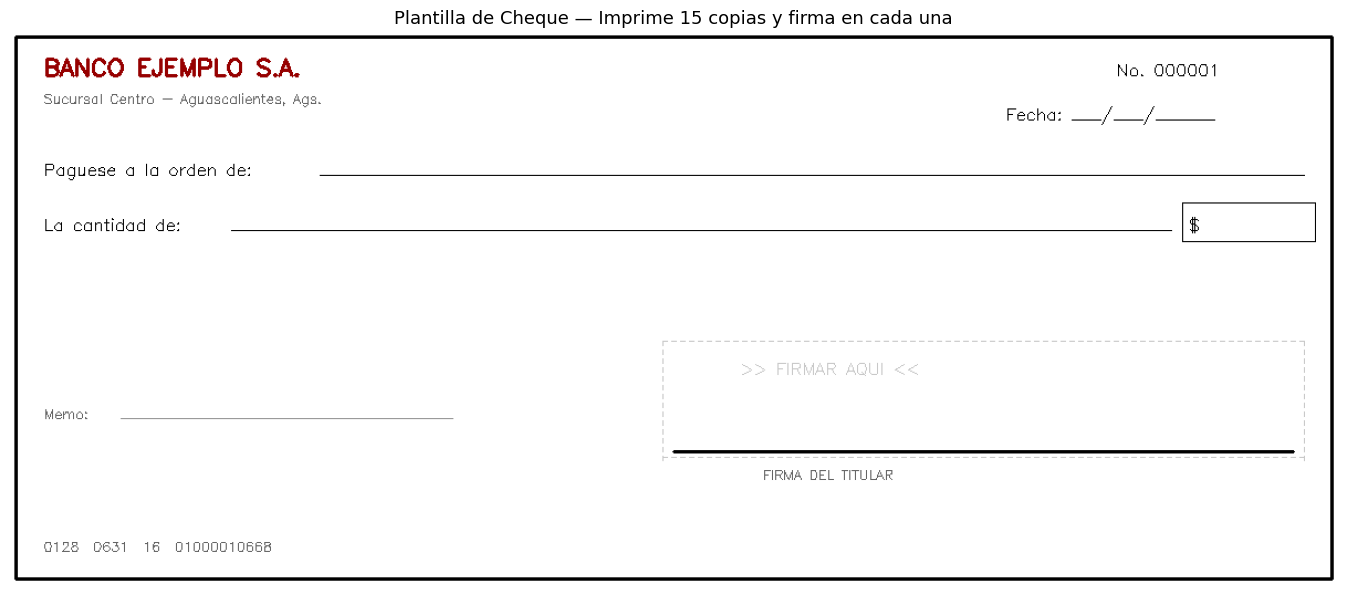

Plantilla guardada en: datos/plantilla_cheque.png
Imprime 15 copias, firma cada una, escanea y guarda en datos/cheques_originales/


In [3]:
# =============================================================================
# 1.2 Generar una plantilla de cheque para imprimir y firmar
# =============================================================================
def generar_plantilla_cheque(output_path='datos/plantilla_cheque.png'):
    """
    Genera una imagen de plantilla de cheque en blanco para imprimir.
    El alumno firmará en la zona indicada (parte inferior derecha).
    """
    # Tamaño del cheque (aprox. 6x2.5 pulgadas a 200 DPI)
    width, height = 1200, 500
    cheque = np.ones((height, width, 3), dtype=np.uint8) * 255
    
    # Borde del cheque
    cv2.rectangle(cheque, (5, 5), (width-5, height-5), (0, 0, 0), 2)
    
    # Nombre del banco
    cv2.putText(cheque, "BANCO EJEMPLO S.A.", (30, 40), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.7, (0, 0, 150), 2)
    cv2.putText(cheque, "Sucursal Centro - Aguascalientes, Ags.", (30, 65), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (100, 100, 100), 1)
    
    # Número de cheque
    cv2.putText(cheque, "No. 000001", (width-200, 40), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    
    # Fecha
    cv2.putText(cheque, "Fecha: ___/___/______", (width-300, 80), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    
    # Páguese a la orden de
    cv2.putText(cheque, "Paguese a la orden de:", (30, 130), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    cv2.line(cheque, (280, 130), (width-30, 130), (0, 0, 0), 1)
    
    # Cantidad en letra
    cv2.putText(cheque, "La cantidad de:", (30, 180), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    cv2.line(cheque, (200, 180), (width-150, 180), (0, 0, 0), 1)
    
    # Cantidad en número
    cv2.rectangle(cheque, (width-140, 155), (width-20, 190), (0, 0, 0), 1)
    cv2.putText(cheque, "$", (width-135, 180), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (0, 0, 0), 1)
    
    # Memo
    cv2.putText(cheque, "Memo:", (30, 350), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (100, 100, 100), 1)
    cv2.line(cheque, (100, 350), (400, 350), (150, 150, 150), 1)
    
    # ===== ZONA DE FIRMA (lo más importante) =====
    # Línea de firma
    firma_x1, firma_x2 = 600, width - 40
    firma_y = 380
    cv2.line(cheque, (firma_x1, firma_y), (firma_x2, firma_y), (0, 0, 0), 2)
    cv2.putText(cheque, "FIRMA DEL TITULAR", (firma_x1 + 80, firma_y + 25), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (100, 100, 100), 1)
    
    # Rectángulo punteado para indicar zona de firma
    for x in range(firma_x1 - 10, firma_x2 + 10, 8):
        cv2.line(cheque, (x, 280), (x+4, 280), (200, 200, 200), 1)
        cv2.line(cheque, (x, firma_y + 5), (x+4, firma_y + 5), (200, 200, 200), 1)
    for y in range(280, firma_y + 5, 8):
        cv2.line(cheque, (firma_x1-10, y), (firma_x1-10, y+4), (200, 200, 200), 1)
        cv2.line(cheque, (firma_x2+10, y), (firma_x2+10, y+4), (200, 200, 200), 1)
    
    cv2.putText(cheque, ">> FIRMAR AQUI <<", (firma_x1 + 60, 310), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
    
    # Números MICR (simulados)
    cv2.putText(cheque, "0128  0631  16  01000010668", (30, height-30), 
                cv2.FONT_HERSHEY_SIMPLEX, 0.4, (100, 100, 100), 1)
    
    cv2.imwrite(output_path, cheque)
    return cheque

# Generar y mostrar la plantilla
plantilla = generar_plantilla_cheque()

plt.figure(figsize=(14, 6))
plt.imshow(cv2.cvtColor(plantilla, cv2.COLOR_BGR2RGB))
plt.title('Plantilla de Cheque — Imprime 15 copias y firma en cada una', fontsize=13)
plt.axis('off')
plt.tight_layout()
plt.savefig('resultados/graficas/plantilla_cheque.png', dpi=150, bbox_inches='tight')
plt.show()

print("Plantilla guardada en: datos/plantilla_cheque.png")
print("Imprime 15 copias, firma cada una, escanea y guarda en datos/cheques_originales/")


Cheques cargados: 15


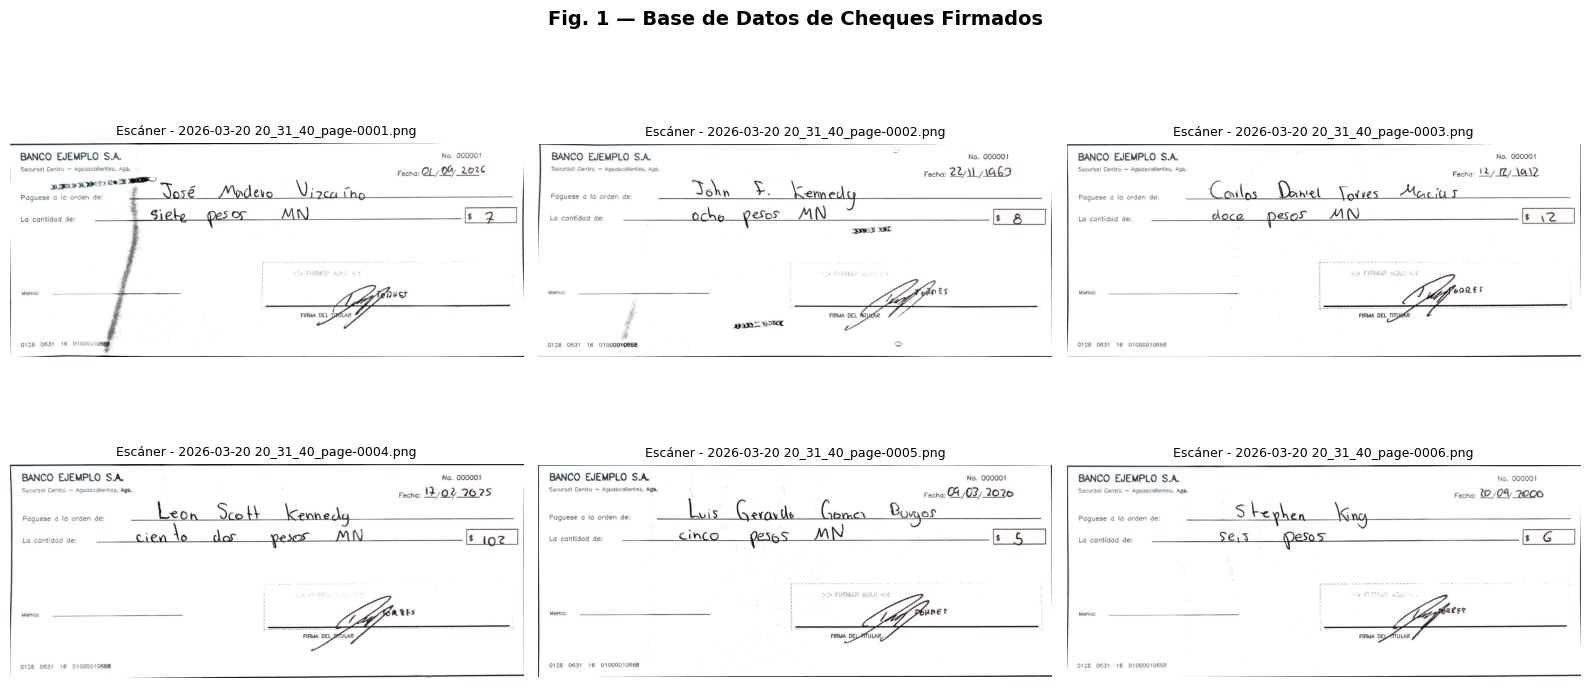

In [4]:
# =============================================================================
# 1.3 Cargar y visualizar la base de datos de cheques firmados
# =============================================================================
def cargar_cheques(directorio='datos/cheques_originales'):
    """Carga todas las imágenes de cheques desde el directorio."""
    extensiones = ['*.png', '*.jpg', '*.jpeg', '*.bmp', '*.tiff']
    imagenes = []
    nombres = []
    
    for ext in extensiones:
        archivos = sorted(glob.glob(os.path.join(directorio, ext)))
        for archivo in archivos:
            img = cv2.imread(archivo)
            if img is not None:
                imagenes.append(img)
                nombres.append(os.path.basename(archivo))
    
    return imagenes, nombres

# Cargar cheques
cheques, nombres_cheques = cargar_cheques()
print(f"Cheques cargados: {len(cheques)}")

if len(cheques) > 0:
    # Mostrar los primeros cheques de la base de datos
    n_mostrar = min(6, len(cheques))
    fig, axes = plt.subplots(2, 3, figsize=(16, 8))
    fig.suptitle('Fig. 1 — Base de Datos de Cheques Firmados', fontsize=14, fontweight='bold')
    
    for i, ax in enumerate(axes.flat):
        if i < n_mostrar:
            ax.imshow(cv2.cvtColor(cheques[i], cv2.COLOR_BGR2RGB))
            ax.set_title(nombres_cheques[i], fontsize=9)
        ax.axis('off')
    
    plt.tight_layout()
    plt.savefig('resultados/graficas/base_datos_cheques.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print("\n*** ATENCIÓN: No se encontraron imágenes en datos/cheques_originales/ ***")
    print("Sigue las instrucciones arriba para generar tu base de datos.")
    print("\n--- MODO DEMO: Generando datos sintéticos para demostrar el pipeline ---")


In [5]:
# =============================================================================
# 1.4 MODO DEMO — Generar firmas sintéticas si no hay imágenes reales
# =============================================================================
# Este bloque genera firmas artificiales para que puedas probar todo el pipeline
# SIN NECESIDAD de imágenes reales. Cuando tengas tus cheques escaneados,
# simplemente colócalos en datos/cheques_originales/ y vuelve a ejecutar desde 1.3.

def generar_firma_sintetica(seed=None):
    """Genera una imagen de firma sintética con trazos aleatorios."""
    if seed is not None:
        np.random.seed(seed)
    
    img = np.ones((150, 400), dtype=np.uint8) * 255
    
    # Generar trazos curvos aleatorios que simulan una firma
    n_trazos = np.random.randint(3, 7)
    for _ in range(n_trazos):
        n_puntos = np.random.randint(5, 15)
        x_start = np.random.randint(20, 100)
        y_start = np.random.randint(30, 120)
        
        puntos = [(x_start, y_start)]
        for j in range(n_puntos):
            dx = np.random.randint(10, 40)
            dy = np.random.randint(-30, 30)
            new_x = min(max(puntos[-1][0] + dx, 5), 395)
            new_y = min(max(puntos[-1][1] + dy, 5), 145)
            puntos.append((new_x, new_y))
        
        pts = np.array(puntos, dtype=np.int32).reshape(-1, 1, 2)
        grosor = np.random.randint(1, 4)
        cv2.polylines(img, [pts], False, 0, grosor, cv2.LINE_AA)
    
    return img

def generar_firma_en_cheque(firma_img, plantilla):
    """Coloca una firma sintética en la zona de firma del cheque."""
    cheque = plantilla.copy()
    # Zona de firma: aproximadamente (600, 280) a (1160, 380)
    zona_h, zona_w = 100, 560
    firma_resized = cv2.resize(firma_img, (zona_w, zona_h))
    
    # Convertir firma a 3 canales
    if len(firma_resized.shape) == 2:
        firma_3ch = cv2.cvtColor(firma_resized, cv2.COLOR_GRAY2BGR)
    else:
        firma_3ch = firma_resized
    
    # Colocar en zona de firma con blending
    y1, y2 = 285, 285 + zona_h
    x1, x2 = 600, 600 + zona_w
    mask = firma_resized < 128
    if len(mask.shape) == 2:
        mask_3d = np.stack([mask]*3, axis=-1)
    else:
        mask_3d = mask
    
    cheque[y1:y2, x1:x2][mask_3d] = firma_3ch[mask_3d]
    return cheque

if len(cheques) == 0:
    print("Generando 15 cheques con firmas sintéticas para demo...\n")
    
    plantilla = generar_plantilla_cheque()
    cheques = []
    nombres_cheques = []
    
    for i in range(15):
        firma = generar_firma_sintetica(seed=42 + i)  # Misma "persona", variaciones
        cheque_firmado = generar_firma_en_cheque(firma, plantilla)
        
        nombre = f'firma_demo_{i+1:02d}.png'
        ruta = os.path.join('datos/cheques_originales', nombre)
        cv2.imwrite(ruta, cheque_firmado)
        
        cheques.append(cheque_firmado)
        nombres_cheques.append(nombre)
    
    print(f"Se generaron {len(cheques)} cheques con firmas sintéticas.")
    
    # Visualizar
    fig, axes = plt.subplots(3, 5, figsize=(18, 9))
    fig.suptitle('Fig. 1 — Base de Datos de Cheques (modo demo)', fontsize=14, fontweight='bold')
    for i, ax in enumerate(axes.flat):
        if i < len(cheques):
            ax.imshow(cv2.cvtColor(cheques[i], cv2.COLOR_BGR2RGB))
            ax.set_title(f'Firma {i+1}', fontsize=8)
        ax.axis('off')
    plt.tight_layout()
    plt.savefig('resultados/graficas/base_datos_cheques.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print(f"Usando {len(cheques)} cheques reales cargados.")


Usando 15 cheques reales cargados.


---
## Etapa 2: Pre-procesamiento de Datos (25%)

### Segmentación y extracción de firmas off-line en cheques

En cada imagen del cheque hay múltiples elementos (texto, números, logos, líneas). La firma se encuentra en una **región fija** (parte inferior derecha). El proceso es:

1. **Localizar** la región de firma en el cheque (ROI).
2. **Extraer** la región de interés.
3. **Binarizar** la imagen (convertir a blanco y negro).
4. **Limpiar ruido** mediante operaciones morfológicas.


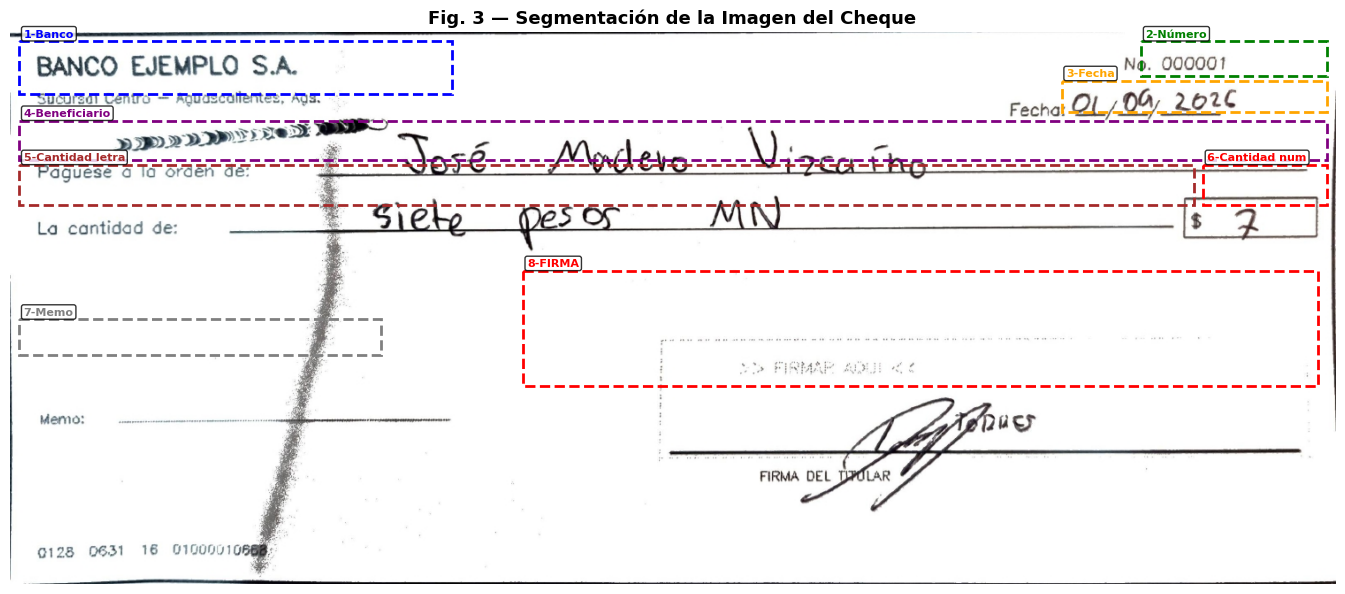

La región 8 (FIRMA) es la zona de interés que extraeremos.


In [6]:
# =============================================================================
# 2.1 Segmentación del cheque — Identificar regiones
# =============================================================================
def mostrar_segmentacion_cheque(cheque_img):
    """Muestra las regiones principales del cheque (como Fig. 3 del documento)."""
    fig, ax = plt.subplots(1, 1, figsize=(14, 6))
    img_rgb = cv2.cvtColor(cheque_img, cv2.COLOR_BGR2RGB)
    ax.imshow(img_rgb)
    
    h, w = cheque_img.shape[:2]
    
    # Regiones del cheque (aproximadas)
    regiones = {
        '1-Banco': (10, 10, w//3, 70),
        '2-Número': (w-220, 10, w-10, 50),
        '3-Fecha': (w-310, 55, w-10, 90),
        '4-Beneficiario': (10, 100, w-10, 145),
        '5-Cantidad letra': (10, 150, w-160, 195),
        '6-Cantidad num': (w-150, 150, w-10, 195),
        '7-Memo': (10, 325, 420, 365),
        '8-FIRMA': (580, 270, w-20, 400),
    }
    
    colores = ['blue', 'green', 'orange', 'purple', 'brown', 'red', 'gray', 'red']
    
    for (nombre, (x1, y1, x2, y2)), color in zip(regiones.items(), colores):
        rect = plt.Rectangle((x1, y1), x2-x1, y2-y1, 
                             linewidth=2, edgecolor=color, facecolor='none', linestyle='--')
        ax.add_patch(rect)
        ax.text(x1+5, y1-5, nombre, fontsize=8, color=color, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.8))
    
    ax.set_title('Fig. 3 — Segmentación de la Imagen del Cheque', fontsize=13, fontweight='bold')
    ax.axis('off')
    plt.tight_layout()
    plt.savefig('resultados/graficas/segmentacion_cheque.png', dpi=150, bbox_inches='tight')
    plt.show()

# Mostrar segmentación del primer cheque
mostrar_segmentacion_cheque(cheques[0])
print("La región 8 (FIRMA) es la zona de interés que extraeremos.")


In [7]:
# =============================================================================
# 2.2 Extracción de la firma del cheque
# =============================================================================
def extraer_firma(cheque_img, roi=None):
    """
    Extrae la región de firma del cheque.
    
    Parámetros:
    -----------
    cheque_img : imagen BGR del cheque
    roi : tupla (x1, y1, x2, y2) con la región de la firma.
          Si es None, usa la región por defecto (inferior derecha).
    
    Retorna:
    --------
    firma_gray : imagen en escala de grises de la firma
    firma_bin  : imagen binarizada de la firma
    """
    h, w = cheque_img.shape[:2]
    
    if roi is None:
        # Región por defecto (parte inferior derecha del cheque)
        # Ajusta estos valores según tu plantilla/escaneo
        x1 = int(w * 0.48)
        y1 = int(h * 0.54)
        x2 = int(w * 0.97)
        y2 = int(h * 0.78)
    else:
        x1, y1, x2, y2 = roi
    
    # Extraer ROI
    firma_roi = cheque_img[y1:y2, x1:x2]
    
    # Convertir a escala de grises
    firma_gray = cv2.cvtColor(firma_roi, cv2.COLOR_BGR2GRAY)
    
    return firma_gray, (x1, y1, x2, y2)


def binarizar_firma(firma_gray):
    """
    Binariza la imagen de la firma y limpia ruido.
    """
    # Binarización adaptativa (mejor para firmas con iluminación variable)
    firma_bin = cv2.adaptiveThreshold(
        firma_gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
        cv2.THRESH_BINARY_INV, blockSize=15, C=10
    )
    
    # Limpiar ruido pequeño con apertura morfológica
    kernel_limpieza = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (2, 2))
    firma_limpia = cv2.morphologyEx(firma_bin, cv2.MORPH_OPEN, kernel_limpieza)
    
    # Eliminar componentes conectados muy pequeños (ruido)
    n_labels, labels, stats, _ = cv2.connectedComponentsWithStats(firma_limpia)
    area_minima = 10  # píxeles mínimos para considerar como trazo
    
    firma_final = np.zeros_like(firma_limpia)
    for i in range(1, n_labels):  # 0 es fondo
        if stats[i, cv2.CC_STAT_AREA] >= area_minima:
            firma_final[labels == i] = 255
    
    return firma_final


# Extraer y procesar todas las firmas
firmas_gray = []
firmas_binarias = []

print("Extrayendo firmas de los cheques...\n")
for i, cheque in enumerate(cheques):
    firma_g, coords = extraer_firma(cheque)
    firma_b = binarizar_firma(firma_g)
    firmas_gray.append(firma_g)
    firmas_binarias.append(firma_b)
    
    # Guardar firma extraída
    cv2.imwrite(f'datos/firmas_extraidas/firma_{i+1:02d}_gray.png', firma_g)
    cv2.imwrite(f'datos/firmas_procesadas/firma_{i+1:02d}_bin.png', firma_b)

print(f"Se extrajeron {len(firmas_binarias)} firmas.")
print(f"Tamaño típico de firma: {firmas_binarias[0].shape}")


Extrayendo firmas de los cheques...

Se extrajeron 15 firmas.
Tamaño típico de firma: (150, 735)


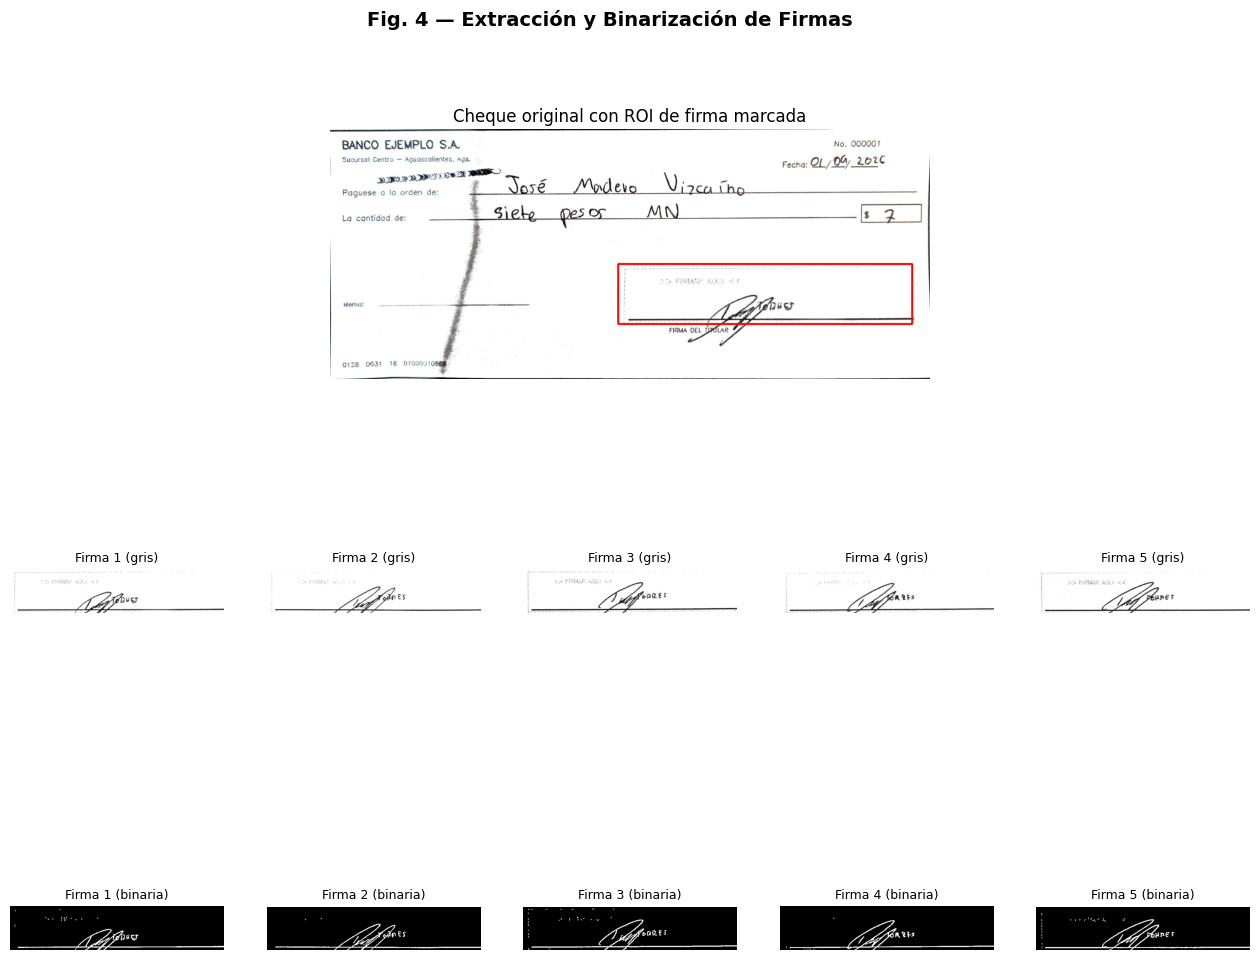

Pre-procesamiento completado exitosamente.


In [8]:
# =============================================================================
# 2.3 Visualización del proceso de extracción (como Fig. 4 del documento)
# =============================================================================
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(3, 5, hspace=0.35, wspace=0.2)

# Fila 1: Cheque original con ROI marcado
ax0 = fig.add_subplot(gs[0, :])
cheque_marcado = cheques[0].copy()
h, w = cheque_marcado.shape[:2]
x1, y1 = int(w*0.48), int(h*0.54)
x2, y2 = int(w*0.97), int(h*0.78)
cv2.rectangle(cheque_marcado, (x1, y1), (x2, y2), (0, 0, 255), 3)
ax0.imshow(cv2.cvtColor(cheque_marcado, cv2.COLOR_BGR2RGB))
ax0.set_title('Cheque original con ROI de firma marcada', fontsize=12)
ax0.axis('off')

# Fila 2: Firmas extraídas (gris)
for i in range(5):
    ax = fig.add_subplot(gs[1, i])
    ax.imshow(firmas_gray[i], cmap='gray')
    ax.set_title(f'Firma {i+1} (gris)', fontsize=9)
    ax.axis('off')

# Fila 3: Firmas binarizadas
for i in range(5):
    ax = fig.add_subplot(gs[2, i])
    ax.imshow(firmas_binarias[i], cmap='gray')
    ax.set_title(f'Firma {i+1} (binaria)', fontsize=9)
    ax.axis('off')

fig.suptitle('Fig. 4 — Extracción y Binarización de Firmas', fontsize=14, fontweight='bold')
plt.savefig('resultados/graficas/extraccion_firmas.png', dpi=150, bbox_inches='tight')
plt.show()

print("Pre-procesamiento completado exitosamente.")


---
## Etapa 3: Almacenamiento y Transformación de Datos Relevantes (25%)

### Extracción de Patrones de la Firma mediante Morfología Matemática

Se utilizan **elementos estructurantes (EE)** para detectar:
- **Trazos curvos** (regiones de baja velocidad): 36 EE
- **Trazos rectos** (regiones de alta velocidad): 18 EE

**Total: 54 elementos estructurantes → vector de 54 características por firma.**

La operación morfológica aplicada es la **erosión**. Al erosionar la imagen de la firma con cada EE, se detecta la presencia de cierto tipo de trazo. El número de píxeles "encendidos" que quedan tras la erosión constituye una característica numérica.


In [9]:
# =============================================================================
# 3.1 Definición de Elementos Estructurantes (EE)
# =============================================================================

def crear_elementos_estructurantes():
    """
    Crea los 54 elementos estructurantes:
    - 36 para detectar trazos curvos (baja velocidad)
    - 18 para detectar trazos rectos (alta velocidad)
    
    Basado en [Lee 96] y el documento del proyecto.
    """
    elementos = []
    nombres = []
    
    # =========================================================================
    # PARTE A: 36 EE para CURVAS (regiones de baja velocidad)
    # =========================================================================
    # Curvas tipo paréntesis derecho ) — diferentes tamaños
    curvas_derecha = [
        np.array([[0,1,1,0],
                  [0,1,1,0],
                  [0,1,1,0],
                  [0,1,1,0]], dtype=np.uint8),
        np.array([[0,0,1,1,0],
                  [0,1,1,0,0],
                  [0,1,0,0,0],
                  [0,1,1,0,0],
                  [0,0,1,1,0]], dtype=np.uint8),
        np.array([[0,0,0,1,0],
                  [0,0,1,0,0],
                  [0,1,0,0,0],
                  [0,1,0,0,0],
                  [0,0,1,0,0],
                  [0,0,0,1,0]], dtype=np.uint8),
    ]
    
    # Curvas tipo paréntesis izquierdo (
    curvas_izquierda = [
        np.array([[0,1,1,0],
                  [0,1,1,0],
                  [0,1,1,0],
                  [0,1,1,0]], dtype=np.uint8),
        np.array([[0,1,1,0,0],
                  [0,0,1,1,0],
                  [0,0,0,1,0],
                  [0,0,1,1,0],
                  [0,1,1,0,0]], dtype=np.uint8),
        np.array([[0,1,0,0,0],
                  [0,0,1,0,0],
                  [0,0,0,1,0],
                  [0,0,0,1,0],
                  [0,0,1,0,0],
                  [0,1,0,0,0]], dtype=np.uint8),
    ]
    
    # Curvas tipo arco superior
    arcos_sup = [
        np.array([[0,0,1,0,0],
                  [0,1,0,1,0],
                  [0,0,0,0,0]], dtype=np.uint8),
        np.array([[0,0,1,1,0,0],
                  [0,1,0,0,1,0],
                  [1,0,0,0,0,1],
                  [0,0,0,0,0,0]], dtype=np.uint8),
        np.array([[0,0,0,1,1,0,0,0],
                  [0,0,1,0,0,1,0,0],
                  [0,1,0,0,0,0,1,0],
                  [0,0,0,0,0,0,0,0]], dtype=np.uint8),
    ]
    
    # Curvas tipo arco inferior
    arcos_inf = [
        np.array([[0,0,0,0,0],
                  [0,1,0,1,0],
                  [0,0,1,0,0]], dtype=np.uint8),
        np.array([[0,0,0,0,0,0],
                  [1,0,0,0,0,1],
                  [0,1,0,0,1,0],
                  [0,0,1,1,0,0]], dtype=np.uint8),
        np.array([[0,0,0,0,0,0,0,0],
                  [0,1,0,0,0,0,1,0],
                  [0,0,1,0,0,1,0,0],
                  [0,0,0,1,1,0,0,0]], dtype=np.uint8),
    ]
    
    # Combinar curvas y generar rotaciones para llegar a 36
    curvas_base = curvas_derecha + curvas_izquierda + arcos_sup + arcos_inf
    
    for i, ee in enumerate(curvas_base):
        elementos.append(ee)
        nombres.append(f'Curva_{i+1}')
        # Rotaciones 90°, 180°, 270° (si no es simétrico)
        for rot in [1, 2, 3]:
            ee_rot = np.rot90(ee, rot)
            if len(elementos) < 36:
                elementos.append(ee_rot)
                nombres.append(f'Curva_{i+1}_rot{rot*90}')
    
    # Asegurar exactamente 36 EE para curvas
    while len(elementos) < 36:
        # Generar variaciones adicionales
        size = np.random.choice([3, 4, 5])
        ee_extra = np.zeros((size, size), dtype=np.uint8)
        # Crear patrón curvo
        for j in range(size):
            col = min(size-1, max(0, int(size/2 + 1.5*np.sin(2*np.pi*j/size))))
            ee_extra[j, col] = 1
        elementos.append(ee_extra)
        nombres.append(f'Curva_extra_{len(elementos)}')
    
    elementos = elementos[:36]
    nombres = nombres[:36]
    
    # =========================================================================
    # PARTE B: 18 EE para TRAZOS RECTOS (regiones de alta velocidad)
    # =========================================================================
    # Basado en Fig. 6 del documento — líneas rectas en diferentes ángulos
    
    # Diagonal principal (\\)
    rectas = []
    for size in [3, 4, 5]:
        ee = np.zeros((size, size), dtype=np.uint8)
        for j in range(size):
            ee[j, j] = 1
        rectas.append(ee)
    
    # Diagonal inversa (/)
    for size in [3, 4, 5]:
        ee = np.zeros((size, size), dtype=np.uint8)
        for j in range(size):
            ee[j, size-1-j] = 1
        rectas.append(ee)
    
    # Horizontal (—)
    for size in [3, 5, 7]:
        ee = np.zeros((3, size), dtype=np.uint8)
        ee[1, :] = 1
        rectas.append(ee)
    
    # Vertical (|)
    for size in [3, 5, 7]:
        ee = np.zeros((size, 3), dtype=np.uint8)
        ee[:, 1] = 1
        rectas.append(ee)
    
    # Diagonales con inclinación intermedia
    ee_45_1 = np.array([[1,0,0,0,0],
                         [0,1,0,0,0],
                         [0,0,1,0,0],
                         [0,0,0,1,0],
                         [0,0,0,0,1]], dtype=np.uint8)
    rectas.append(ee_45_1)
    
    ee_135 = np.array([[0,0,0,0,1],
                        [0,0,0,1,0],
                        [0,0,1,0,0],
                        [0,1,0,0,0],
                        [1,0,0,0,0]], dtype=np.uint8)
    rectas.append(ee_135)
    
    # Línea con ligera inclinación
    ee_slight1 = np.array([[1,0,0,0,0],
                            [0,1,1,0,0],
                            [0,0,0,1,0],
                            [0,0,0,0,1]], dtype=np.uint8)
    rectas.append(ee_slight1)
    
    ee_slight2 = np.array([[0,0,0,0,1],
                            [0,0,1,1,0],
                            [0,1,0,0,0],
                            [1,0,0,0,0]], dtype=np.uint8)
    rectas.append(ee_slight2)
    
    # Cruz y T
    ee_cruz = np.array([[0,1,0],
                         [1,1,1],
                         [0,1,0]], dtype=np.uint8)
    rectas.append(ee_cruz)
    
    ee_t = np.array([[1,1,1],
                      [0,1,0],
                      [0,1,0]], dtype=np.uint8)
    rectas.append(ee_t)
    
    # Asegurar exactamente 18 EE rectos
    while len(rectas) < 18:
        size = 5
        ee = np.zeros((size, size), dtype=np.uint8)
        angulo = np.random.uniform(0, np.pi)
        for j in range(size):
            r = int(size/2 + (j - size/2) * np.sin(angulo))
            c = int(size/2 + (j - size/2) * np.cos(angulo))
            r = min(size-1, max(0, r))
            c = min(size-1, max(0, c))
            ee[r, c] = 1
        rectas.append(ee)
    
    rectas = rectas[:18]
    
    for i, ee in enumerate(rectas):
        elementos.append(ee)
        nombres.append(f'Recta_{i+1}')
    
    return elementos, nombres


# Crear los 54 elementos estructurantes
elementos_estructurantes, nombres_ee = crear_elementos_estructurantes()
print(f"Total de elementos estructurantes creados: {len(elementos_estructurantes)}")
print(f"  - Para curvas (baja velocidad): 36")
print(f"  - Para rectas (alta velocidad): 18")


Total de elementos estructurantes creados: 54
  - Para curvas (baja velocidad): 36
  - Para rectas (alta velocidad): 18


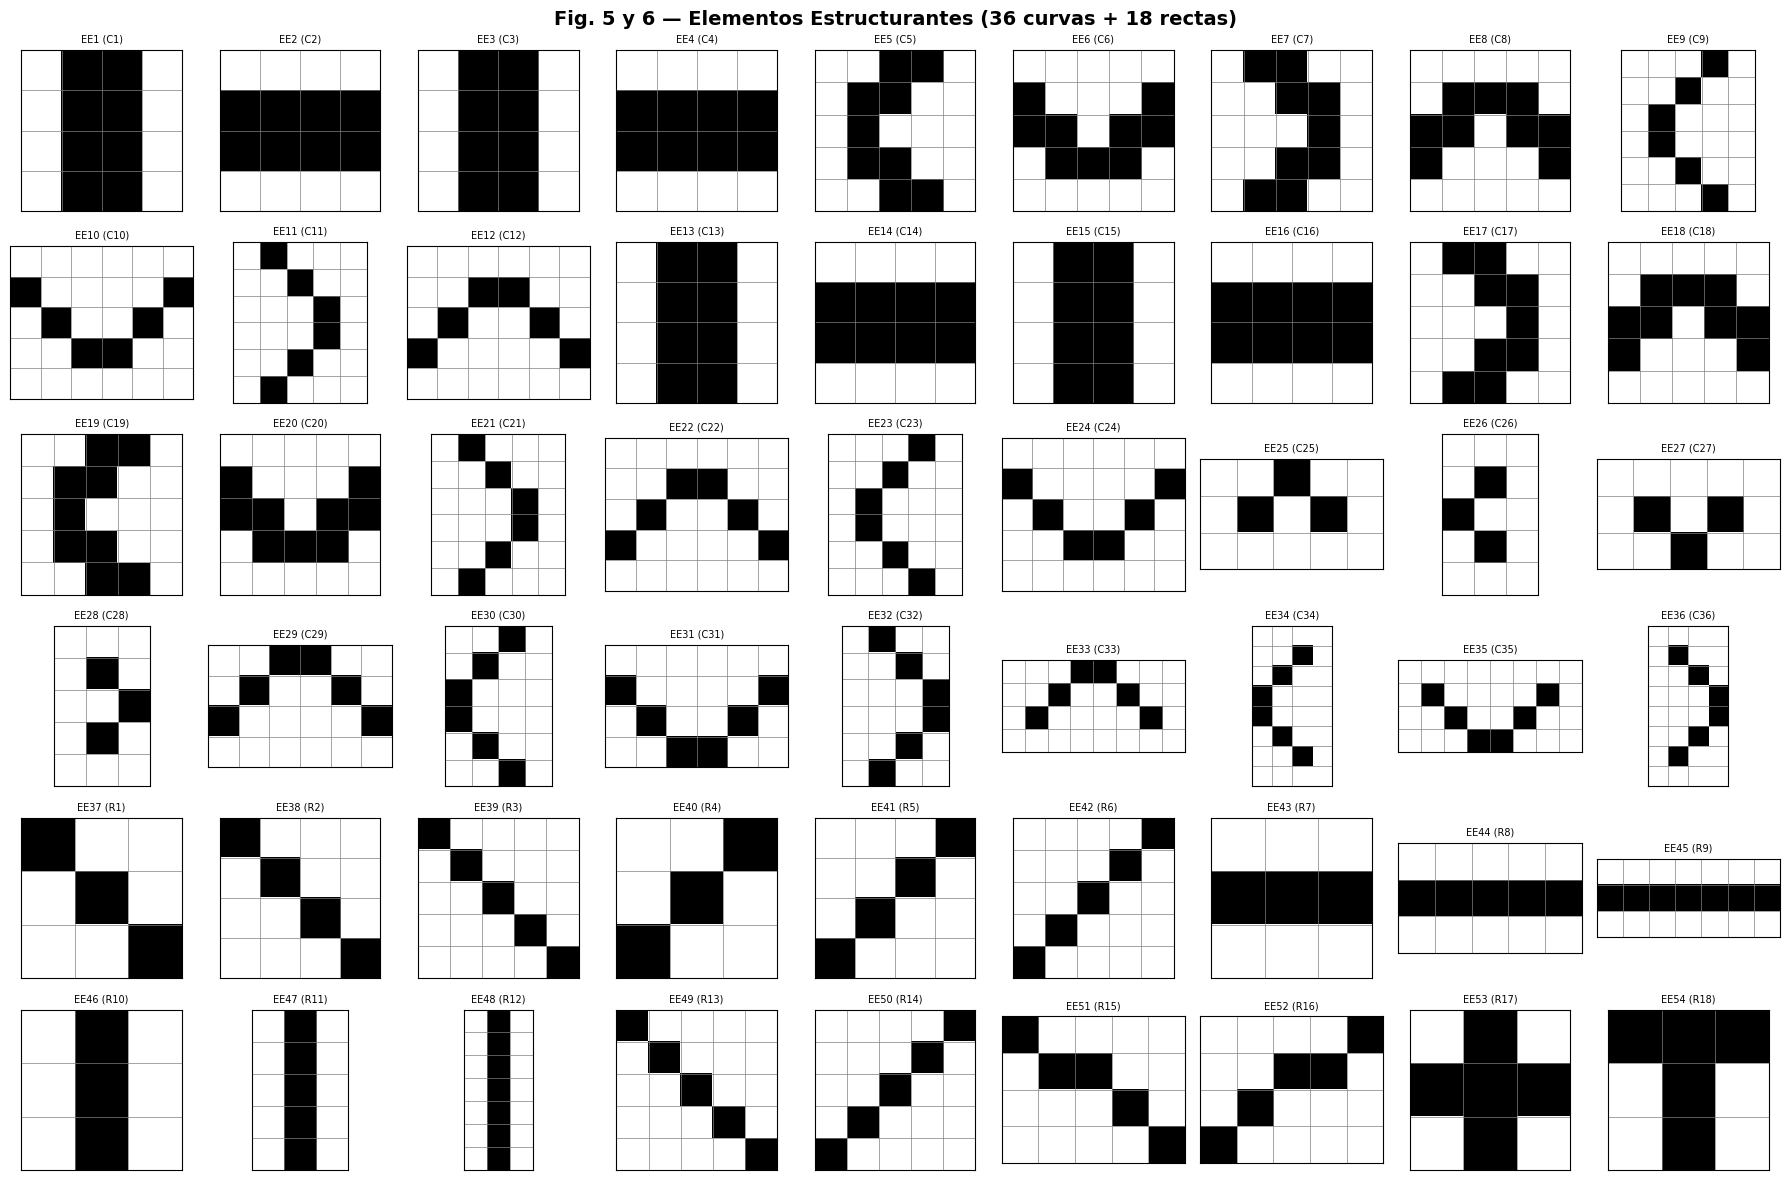

In [10]:
# =============================================================================
# 3.2 Visualizar los elementos estructurantes (como Fig. 5 y Fig. 6)
# =============================================================================
fig, axes = plt.subplots(6, 9, figsize=(18, 12))
fig.suptitle('Fig. 5 y 6 — Elementos Estructurantes (36 curvas + 18 rectas)', 
             fontsize=14, fontweight='bold')

for i, ax in enumerate(axes.flat):
    if i < len(elementos_estructurantes):
        ax.imshow(elementos_estructurantes[i], cmap='gray_r', interpolation='nearest')
        tipo = 'C' if i < 36 else 'R'
        num = i + 1 if i < 36 else i - 35
        ax.set_title(f'EE{i+1} ({tipo}{num})', fontsize=7)
        
        # Mostrar grid
        ax.set_xticks(np.arange(-0.5, elementos_estructurantes[i].shape[1], 1), minor=True)
        ax.set_yticks(np.arange(-0.5, elementos_estructurantes[i].shape[0], 1), minor=True)
        ax.grid(which='minor', color='gray', linewidth=0.5)
        ax.tick_params(which='both', bottom=False, left=False, labelbottom=False, labelleft=False)
    else:
        ax.axis('off')

plt.tight_layout()
plt.savefig('resultados/graficas/elementos_estructurantes.png', dpi=150, bbox_inches='tight')
plt.show()


In [11]:
# =============================================================================
# 3.3 Extracción de vectores de características mediante erosión
# =============================================================================
def extraer_caracteristicas(firma_bin, elementos_est):
    """
    Erosiona la firma con cada elemento estructurante y cuenta los píxeles
    que quedan encendidos. Esto forma el vector de características.
    
    Parámetros:
    -----------
    firma_bin : imagen binaria de la firma (0 y 255)
    elementos_est : lista de elementos estructurantes
    
    Retorna:
    --------
    vector : np.array de tamaño (n_elementos,) con el conteo de píxeles
    """
    # Normalizar a 0/1 si viene en 0/255
    firma_01 = (firma_bin > 0).astype(np.uint8)
    
    vector = np.zeros(len(elementos_est), dtype=np.float64)
    
    for i, ee in enumerate(elementos_est):
        # Aplicar erosión
        img_erosionada = cv2.erode(firma_01, ee, iterations=1)
        # Contar píxeles encendidos
        vector[i] = np.sum(img_erosionada)
    
    return vector


# Normalizar el tamaño de todas las firmas a una dimensión común
TAMANO_FIRMA = (200, 400)  # (alto, ancho) estándar

firmas_normalizadas = []
for fb in firmas_binarias:
    firma_norm = cv2.resize(fb, (TAMANO_FIRMA[1], TAMANO_FIRMA[0]))
    _, firma_norm = cv2.threshold(firma_norm, 127, 255, cv2.THRESH_BINARY)
    firmas_normalizadas.append(firma_norm)

# Extraer características de las 10 primeras firmas (entrenamiento)
# Las últimas 5 se reservan para test
N_FIRMAS_TRAIN = 10
N_FIRMAS_TEST = min(5, len(firmas_normalizadas) - N_FIRMAS_TRAIN)

print(f"Firmas para entrenamiento: {N_FIRMAS_TRAIN}")
print(f"Firmas para test: {N_FIRMAS_TEST}")
print(f"Extrayendo vectores de características (54 dimensiones)...\n")

# Patrones REALES (filas 1-10 de la Tabla 1)
patrones_reales = np.zeros((N_FIRMAS_TRAIN, 54))
for i in range(N_FIRMAS_TRAIN):
    patrones_reales[i] = extraer_caracteristicas(
        firmas_normalizadas[i], elementos_estructurantes
    )
    print(f"  Firma {i+1}: vector extraído — "
          f"min={patrones_reales[i].min():.0f}, max={patrones_reales[i].max():.0f}, "
          f"media={patrones_reales[i].mean():.1f}")

print(f"\nMatriz de patrones reales: {patrones_reales.shape}")


Firmas para entrenamiento: 10
Firmas para test: 5
Extrayendo vectores de características (54 dimensiones)...

  Firma 1: vector extraído — min=242, max=2526, media=1146.2
  Firma 2: vector extraído — min=288, max=2606, media=1197.3
  Firma 3: vector extraído — min=232, max=2834, media=1288.9
  Firma 4: vector extraído — min=319, max=2802, media=1271.4
  Firma 5: vector extraído — min=317, max=3038, media=1364.8
  Firma 6: vector extraído — min=378, max=2916, media=1376.9
  Firma 7: vector extraído — min=521, max=4015, media=1638.3
  Firma 8: vector extraído — min=311, max=2870, media=1314.4
  Firma 9: vector extraído — min=492, max=3185, media=1593.4
  Firma 10: vector extraído — min=293, max=2715, media=1085.4

Matriz de patrones reales: (10, 54)


In [12]:
# =============================================================================
# 3.4 Generación de patrones sintéticos (positivos y negativos)
# =============================================================================

def generar_patrones_sinteticos_positivos(patrones_reales, n_sinteticos=50):
    """
    Genera patrones sintéticos positivos basados en la distribución
    estadística de los patrones reales.
    
    Para cada columna (EE), se generan valores en el rango:
        [media - sigma, media + sigma]
    donde media y sigma se calculan de los patrones reales.
    """
    n_features = patrones_reales.shape[1]
    medias = patrones_reales.mean(axis=0)
    stds = patrones_reales.std(axis=0)
    
    sinteticos = np.zeros((n_sinteticos, n_features))
    for j in range(n_features):
        low = max(0, medias[j] - stds[j])
        high = medias[j] + stds[j]
        if low >= high:
            high = low + 1
        sinteticos[:, j] = np.random.uniform(low, high, n_sinteticos)
    
    return sinteticos.astype(int)


def generar_patrones_sinteticos_negativos(n_sinteticos=50, n_features=54,
                                          rango_min=1, rango_max=300):
    """
    Genera patrones sintéticos negativos (firmas falsas):
    valores aleatorios en el rango [1, 300].
    """
    sinteticos = np.random.uniform(rango_min, rango_max, 
                                    (n_sinteticos, n_features))
    return sinteticos.astype(int)


# Generar patrones sintéticos
np.random.seed(42)  # Reproducibilidad

N_SINTETICOS_POS = 50
N_SINTETICOS_NEG = 50

patrones_sinteticos_pos = generar_patrones_sinteticos_positivos(
    patrones_reales, N_SINTETICOS_POS
)
patrones_sinteticos_neg = generar_patrones_sinteticos_negativos(
    N_SINTETICOS_NEG, n_features=54
)

print("Resumen de patrones generados:")
print(f"  Patrones reales (genuinos):          {patrones_reales.shape[0]} x {patrones_reales.shape[1]}")
print(f"  Patrones sintéticos positivos:       {patrones_sinteticos_pos.shape[0]} x {patrones_sinteticos_pos.shape[1]}")
print(f"  Patrones sintéticos negativos:       {patrones_sinteticos_neg.shape[0]} x {patrones_sinteticos_neg.shape[1]}")

# Tabla 1 completa
print(f"\n  Total de patrones de entrenamiento:  {patrones_reales.shape[0] + N_SINTETICOS_POS + N_SINTETICOS_NEG}")


Resumen de patrones generados:
  Patrones reales (genuinos):          10 x 54
  Patrones sintéticos positivos:       50 x 54
  Patrones sintéticos negativos:       50 x 54

  Total de patrones de entrenamiento:  110


In [13]:
# =============================================================================
# 3.5 Visualización de la Tabla 1 — Patrones de Conocimiento
# =============================================================================

# Mostrar un extracto de la Tabla 1
print("=" * 90)
print("TABLA 1 — Patrones de Conocimiento para el Aprendizaje")
print("=" * 90)

header = f"{'Tipo':<20} {'Firma':<8}"
for j in range(6):
    header += f" {'EE'+str(j+1):<8}"
header += "  ...  EE54"
print(header)
print("-" * 90)

# Patrones reales
for i in range(min(3, N_FIRMAS_TRAIN)):
    row = f"{'Real':<20} {'Sig '+str(i+1):<8}"
    for j in range(6):
        row += f" {patrones_reales[i,j]:<8.0f}"
    row += f"  ...  {patrones_reales[i,-1]:.0f}"
    print(row)
print(f"{'...':<20} {'...':<8} {'...'}")

# Patrones sintéticos positivos
for i in range(min(3, N_SINTETICOS_POS)):
    idx = N_FIRMAS_TRAIN + i + 1
    row = f"{'Sint. Positivo':<20} {'Sig '+str(idx):<8}"
    for j in range(6):
        row += f" {patrones_sinteticos_pos[i,j]:<8.0f}"
    row += f"  ...  {patrones_sinteticos_pos[i,-1]:.0f}"
    print(row)
print(f"{'...':<20} {'...':<8} {'...'}")

# Patrones sintéticos negativos
for i in range(min(3, N_SINTETICOS_NEG)):
    idx = N_FIRMAS_TRAIN + N_SINTETICOS_POS + i + 1
    row = f"{'Sint. Negativo':<20} {'Sig '+str(idx):<8}"
    for j in range(6):
        row += f" {patrones_sinteticos_neg[i,j]:<8.0f}"
    row += f"  ...  {patrones_sinteticos_neg[i,-1]:.0f}"
    print(row)
print(f"{'...':<20} {'...':<8} {'...'}")
print("=" * 90)


TABLA 1 — Patrones de Conocimiento para el Aprendizaje
Tipo                 Firma    EE1      EE2      EE3      EE4      EE5      EE6       ...  EE54
------------------------------------------------------------------------------------------
Real                 Sig 1    1170     1614     1170     1614     445      1108      ...  1654
Real                 Sig 2    1175     1625     1175     1625     472      1132      ...  1708
Real                 Sig 3    1359     1752     1359     1752     556      1245      ...  1873
...                  ...      ...
Sint. Positivo       Sig 11   1349     1937     1193     1915     606      1160      ...  1788
Sint. Positivo       Sig 12   1610     1869     1468     1681     453      1185      ...  1874
Sint. Positivo       Sig 13   1511     1926     1322     1648     475      1314      ...  1874
...                  ...      ...
Sint. Negativo       Sig 61   156      292      38       6        231      242       ...  104
Sint. Negativo       Sig 62

Dataset completo:
  Total de muestras: 110
  Características:   54
  Genuinas (+1):     60
  Falsas (-1):       50

Partición:
  Entrenamiento: 88 muestras
  Validación:    22 muestras
  Test (firmas reales): 5 muestras


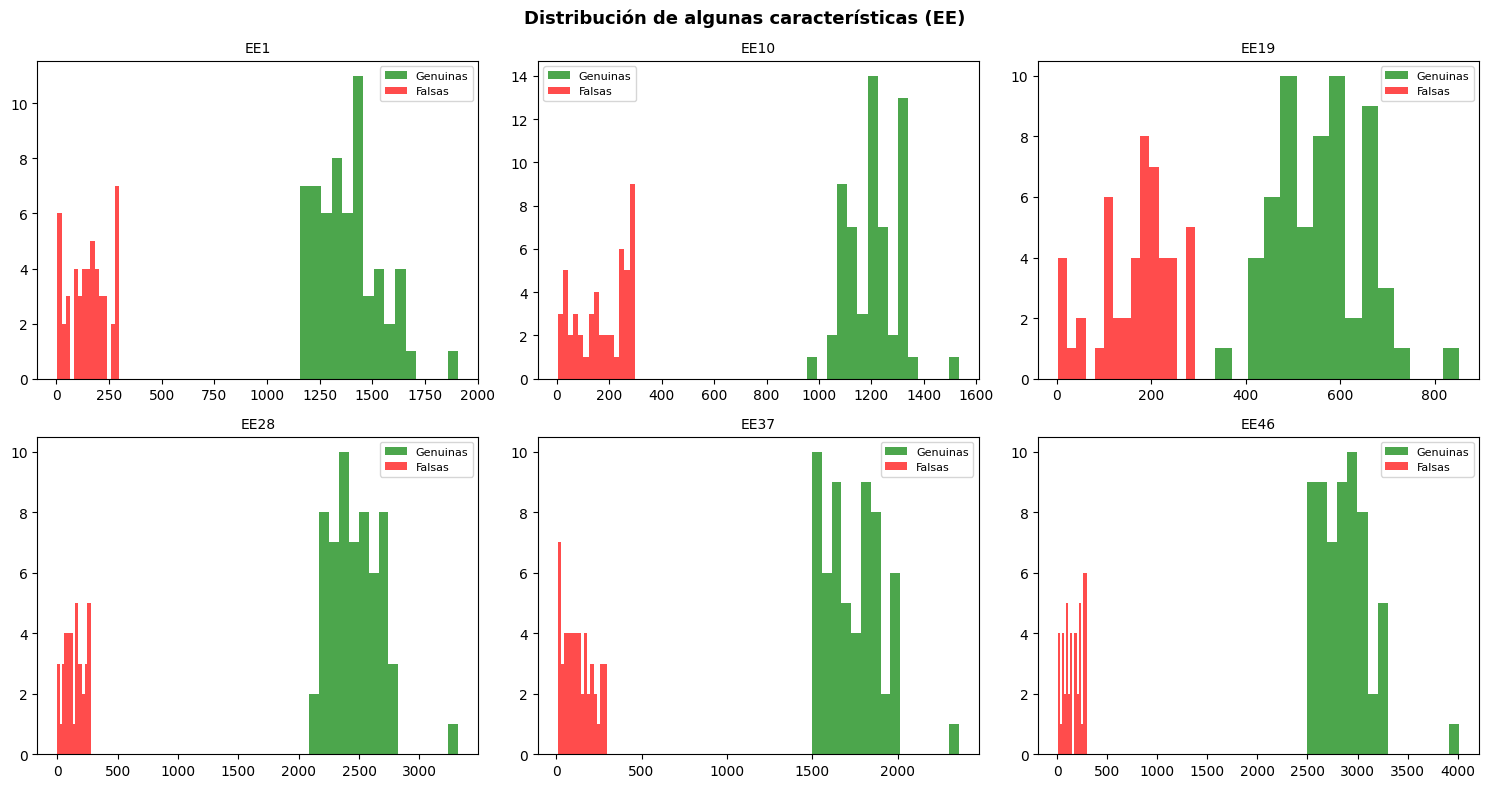

In [14]:
# =============================================================================
# 3.6 Construir el dataset completo (X, y)
# =============================================================================

# Etiquetar: +1 para genuinas (reales + sintéticas positivas), -1 para falsas
X_reales = patrones_reales
y_reales = np.ones(X_reales.shape[0])  # +1

X_sint_pos = patrones_sinteticos_pos
y_sint_pos = np.ones(X_sint_pos.shape[0])  # +1

X_sint_neg = patrones_sinteticos_neg
y_sint_neg = -np.ones(X_sint_neg.shape[0])  # -1

# Combinar todo
X_all = np.vstack([X_reales, X_sint_pos, X_sint_neg])
y_all = np.concatenate([y_reales, y_sint_pos, y_sint_neg])

print(f"Dataset completo:")
print(f"  Total de muestras: {X_all.shape[0]}")
print(f"  Características:   {X_all.shape[1]}")
print(f"  Genuinas (+1):     {np.sum(y_all == 1)}")
print(f"  Falsas (-1):       {np.sum(y_all == -1)}")

# Split entrenamiento / validación
X_train, X_val, y_train, y_val = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all
)

print(f"\nPartición:")
print(f"  Entrenamiento: {X_train.shape[0]} muestras")
print(f"  Validación:    {X_val.shape[0]} muestras")

# Normalización
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# Si hay firmas de test reales, preparar también
if N_FIRMAS_TEST > 0:
    X_test_real = np.zeros((N_FIRMAS_TEST, 54))
    for i in range(N_FIRMAS_TEST):
        idx = N_FIRMAS_TRAIN + i
        X_test_real[i] = extraer_caracteristicas(
            firmas_normalizadas[idx], elementos_estructurantes
        )
    X_test_real_scaled = scaler.transform(X_test_real)
    y_test_real = np.ones(N_FIRMAS_TEST)  # Son firmas genuinas
    print(f"  Test (firmas reales): {N_FIRMAS_TEST} muestras")

# Visualizar distribución de características
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('Distribución de algunas características (EE)', fontsize=13, fontweight='bold')

for i, ax in enumerate(axes.flat):
    ee_idx = i * 9  # EE1, EE10, EE19, EE28, EE37, EE46
    genuinas = X_all[y_all == 1, ee_idx]
    falsas = X_all[y_all == -1, ee_idx]
    
    ax.hist(genuinas, bins=15, alpha=0.7, label='Genuinas', color='green')
    ax.hist(falsas, bins=15, alpha=0.7, label='Falsas', color='red')
    ax.set_title(f'EE{ee_idx+1}', fontsize=10)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('resultados/graficas/distribucion_features.png', dpi=150, bbox_inches='tight')
plt.show()


---
## Etapa 4: Aprendizaje Supervisado (25%)

### Clasificación con 4 Algoritmos

Se implementan los siguientes clasificadores para determinar si una firma es **genuina (+1)** o **falsificada (-1)**:

1. **BPNN** — Backpropagation Neural Network (54-108-1, sigmoidal)
2. **KNN** — K-Nearest Neighbors
3. **Naive Bayes** — Clasificador bayesiano gaussiano
4. **SVM** — Support Vector Machine

Según el documento, la BPNN tiene:
- Capa de entrada: 54 neuronas (una por EE)
- Capa oculta: 108 neuronas
- Capa de salida: 1 neurona (target: +5 genuina, -5 falsa)
- Función de activación: sigmoidal


CLASIFICADOR 1: Backpropagation Neural Network (BPNN)

Arquitectura: 54 -> 108 -> 1
Función de activación: Sigmoidal (logistic)
Épocas realizadas: 12

Accuracy entrenamiento: 1.0000
Accuracy validación:    1.0000

Reporte de clasificación (validación):
              precision    recall  f1-score   support

  Falsa (-1)       1.00      1.00      1.00        10
Genuina (+1)       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22



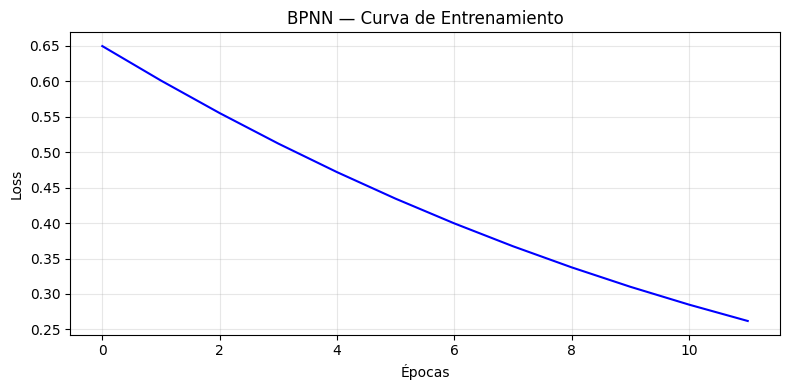

In [15]:
# =============================================================================
# 4.1 Clasificador 1: Backpropagation Neural Network (BPNN)
# =============================================================================
print("=" * 70)
print("CLASIFICADOR 1: Backpropagation Neural Network (BPNN)")
print("=" * 70)

# Arquitectura: 54 entrada -> 108 oculta -> 1 salida (sigmoid)
# MLPClassifier usa logistic (sigmoid) como activación
bpnn = MLPClassifier(
    hidden_layer_sizes=(108,),    # Una capa oculta con 108 neuronas
    activation='logistic',         # Función sigmoidal
    solver='adam',                 # Optimizador Adam (variante de backpropagation)
    max_iter=2000,                 # Épocas máximas
    learning_rate_init=0.001,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    verbose=False
)

bpnn.fit(X_train_scaled, y_train)

# Métricas
y_pred_bpnn_train = bpnn.predict(X_train_scaled)
y_pred_bpnn_val = bpnn.predict(X_val_scaled)

print(f"\nArquitectura: {X_train.shape[1]} -> 108 -> 1")
print(f"Función de activación: Sigmoidal (logistic)")
print(f"Épocas realizadas: {bpnn.n_iter_}")
print(f"\nAccuracy entrenamiento: {accuracy_score(y_train, y_pred_bpnn_train):.4f}")
print(f"Accuracy validación:    {accuracy_score(y_val, y_pred_bpnn_val):.4f}")
print(f"\nReporte de clasificación (validación):")
print(classification_report(y_val, y_pred_bpnn_val, 
                           target_names=['Falsa (-1)', 'Genuina (+1)']))

# Curva de pérdida
plt.figure(figsize=(8, 4))
plt.plot(bpnn.loss_curve_, 'b-', linewidth=1.5)
plt.xlabel('Épocas')
plt.ylabel('Loss')
plt.title('BPNN — Curva de Entrenamiento')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('resultados/graficas/bpnn_loss.png', dpi=150, bbox_inches='tight')
plt.show()


CLASIFICADOR 2: K-Nearest Neighbors (KNN)
  K= 1: Train=1.0000, Val=1.0000
  K= 3: Train=1.0000, Val=1.0000
  K= 5: Train=1.0000, Val=1.0000
  K= 7: Train=1.0000, Val=1.0000
  K= 9: Train=1.0000, Val=1.0000
  K=11: Train=1.0000, Val=1.0000

Mejor K: 1

Reporte de clasificación (validación, K=1):
              precision    recall  f1-score   support

  Falsa (-1)       1.00      1.00      1.00        10
Genuina (+1)       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22



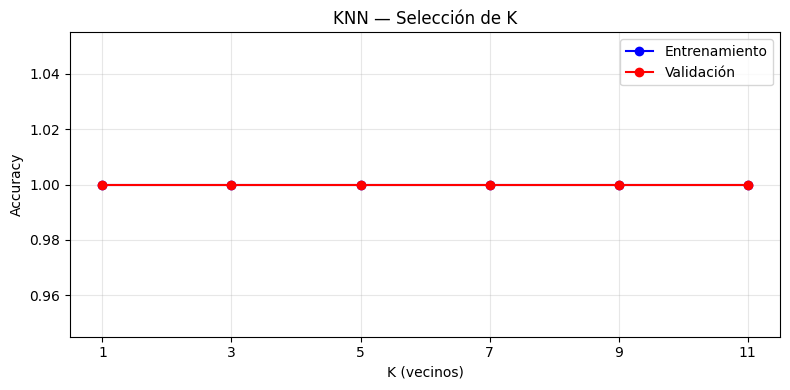

In [16]:
# =============================================================================
# 4.2 Clasificador 2: K-Nearest Neighbors (KNN)
# =============================================================================
print("=" * 70)
print("CLASIFICADOR 2: K-Nearest Neighbors (KNN)")
print("=" * 70)

# Probar diferentes valores de K para encontrar el mejor
ks = [1, 3, 5, 7, 9, 11]
acc_train_k = []
acc_val_k = []

for k in ks:
    knn_temp = KNeighborsClassifier(n_neighbors=k)
    knn_temp.fit(X_train_scaled, y_train)
    acc_train_k.append(accuracy_score(y_train, knn_temp.predict(X_train_scaled)))
    acc_val_k.append(accuracy_score(y_val, knn_temp.predict(X_val_scaled)))
    print(f"  K={k:2d}: Train={acc_train_k[-1]:.4f}, Val={acc_val_k[-1]:.4f}")

# Usar el mejor K
mejor_k = ks[np.argmax(acc_val_k)]
print(f"\nMejor K: {mejor_k}")

knn = KNeighborsClassifier(n_neighbors=mejor_k)
knn.fit(X_train_scaled, y_train)

y_pred_knn_val = knn.predict(X_val_scaled)

print(f"\nReporte de clasificación (validación, K={mejor_k}):")
print(classification_report(y_val, y_pred_knn_val, 
                           target_names=['Falsa (-1)', 'Genuina (+1)']))

# Gráfica K vs Accuracy
plt.figure(figsize=(8, 4))
plt.plot(ks, acc_train_k, 'bo-', label='Entrenamiento')
plt.plot(ks, acc_val_k, 'ro-', label='Validación')
plt.xlabel('K (vecinos)')
plt.ylabel('Accuracy')
plt.title('KNN — Selección de K')
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(ks)
plt.tight_layout()
plt.savefig('resultados/graficas/knn_seleccion_k.png', dpi=150, bbox_inches='tight')
plt.show()


In [17]:
# =============================================================================
# 4.3 Clasificador 3: Naive Bayes (Gaussiano)
# =============================================================================
print("=" * 70)
print("CLASIFICADOR 3: Naive Bayes (Gaussiano)")
print("=" * 70)

nb_clf = GaussianNB()
nb_clf.fit(X_train_scaled, y_train)

y_pred_nb_val = nb_clf.predict(X_val_scaled)

print(f"Accuracy entrenamiento: {accuracy_score(y_train, nb_clf.predict(X_train_scaled)):.4f}")
print(f"Accuracy validación:    {accuracy_score(y_val, y_pred_nb_val):.4f}")
print(f"\nReporte de clasificación (validación):")
print(classification_report(y_val, y_pred_nb_val, 
                           target_names=['Falsa (-1)', 'Genuina (+1)']))


CLASIFICADOR 3: Naive Bayes (Gaussiano)
Accuracy entrenamiento: 1.0000
Accuracy validación:    1.0000

Reporte de clasificación (validación):
              precision    recall  f1-score   support

  Falsa (-1)       1.00      1.00      1.00        10
Genuina (+1)       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22



In [18]:
# =============================================================================
# 4.4 Clasificador 4: Support Vector Machine (SVM)
# =============================================================================
print("=" * 70)
print("CLASIFICADOR 4: Support Vector Machine (SVM)")
print("=" * 70)

# Probar diferentes kernels
kernels = ['linear', 'rbf', 'poly']
for kernel in kernels:
    svm_temp = SVC(kernel=kernel, random_state=42)
    svm_temp.fit(X_train_scaled, y_train)
    acc_t = accuracy_score(y_train, svm_temp.predict(X_train_scaled))
    acc_v = accuracy_score(y_val, svm_temp.predict(X_val_scaled))
    print(f"  Kernel={kernel:6s}: Train={acc_t:.4f}, Val={acc_v:.4f}")

# Usar RBF (generalmente el mejor)
svm_clf = SVC(kernel='rbf', random_state=42, probability=True)
svm_clf.fit(X_train_scaled, y_train)

y_pred_svm_val = svm_clf.predict(X_val_scaled)

print(f"\nReporte de clasificación (validación, kernel=RBF):")
print(classification_report(y_val, y_pred_svm_val, 
                           target_names=['Falsa (-1)', 'Genuina (+1)']))


CLASIFICADOR 4: Support Vector Machine (SVM)
  Kernel=linear: Train=1.0000, Val=1.0000
  Kernel=rbf   : Train=1.0000, Val=1.0000
  Kernel=poly  : Train=1.0000, Val=1.0000

Reporte de clasificación (validación, kernel=RBF):
              precision    recall  f1-score   support

  Falsa (-1)       1.00      1.00      1.00        10
Genuina (+1)       1.00      1.00      1.00        12

    accuracy                           1.00        22
   macro avg       1.00      1.00      1.00        22
weighted avg       1.00      1.00      1.00        22



COMPARACIÓN DE CLASIFICADORES
  BPNN (54-108-1)      — Accuracy: 1.0000 (100.0%)
  KNN (K=1)            — Accuracy: 1.0000 (100.0%)
  Naive Bayes          — Accuracy: 1.0000 (100.0%)
  SVM (RBF)            — Accuracy: 1.0000 (100.0%)


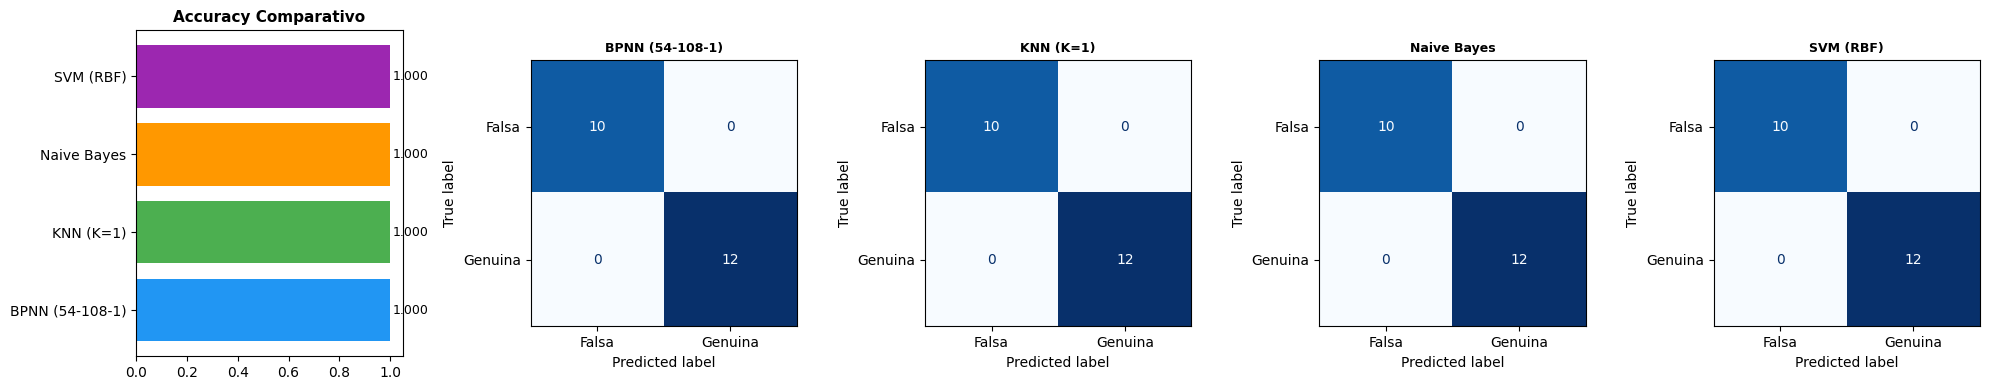

In [19]:
# =============================================================================
# 4.5 Comparación de todos los clasificadores
# =============================================================================
print("=" * 70)
print("COMPARACIÓN DE CLASIFICADORES")
print("=" * 70)

clasificadores = {
    'BPNN (54-108-1)': bpnn,
    f'KNN (K={mejor_k})': knn,
    'Naive Bayes': nb_clf,
    'SVM (RBF)': svm_clf
}

resultados = {}
for nombre, clf in clasificadores.items():
    y_pred = clf.predict(X_val_scaled)
    acc = accuracy_score(y_val, y_pred)
    resultados[nombre] = acc
    print(f"  {nombre:<20s} — Accuracy: {acc:.4f} ({acc*100:.1f}%)")

# Gráfica comparativa
fig, axes = plt.subplots(1, 5, figsize=(20, 4))

# Barras de accuracy
nombres = list(resultados.keys())
accuracies = list(resultados.values())
colores = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

axes[0].barh(nombres, accuracies, color=colores)
axes[0].set_xlim(0, 1.05)
axes[0].set_title('Accuracy Comparativo', fontsize=11, fontweight='bold')
for i, v in enumerate(accuracies):
    axes[0].text(v + 0.01, i, f'{v:.3f}', va='center', fontsize=9)

# Matrices de confusión
preds = [y_pred_bpnn_val, y_pred_knn_val, y_pred_nb_val, y_pred_svm_val]
for i, (nombre, y_pred) in enumerate(zip(nombres, preds)):
    cm = confusion_matrix(y_val, y_pred)
    ConfusionMatrixDisplay(cm, display_labels=['Falsa', 'Genuina']).plot(
        ax=axes[i+1], cmap='Blues', colorbar=False
    )
    axes[i+1].set_title(nombre, fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('resultados/graficas/comparacion_clasificadores.png', dpi=150, bbox_inches='tight')
plt.show()


In [20]:
# =============================================================================
# 4.6 Test con firmas reales reservadas
# =============================================================================
if N_FIRMAS_TEST > 0:
    print("=" * 70)
    print("TEST CON FIRMAS REALES (no vistas durante entrenamiento)")
    print("=" * 70)
    
    for nombre, clf in clasificadores.items():
        predicciones = clf.predict(X_test_real_scaled)
        # Mapear: +1 = Genuina, -1 = Falsa
        n_genuinas = np.sum(predicciones == 1)
        n_falsas = np.sum(predicciones == -1)
        
        print(f"\n  {nombre}:")
        for i in range(N_FIRMAS_TEST):
            resultado = "GENUINA" if predicciones[i] == 1 else "FALSA"
            simbolo = "+" if predicciones[i] == 1 else "x"
            print(f"    Firma test {i+1}: [{simbolo}] {resultado}")
        print(f"    Resultado: {n_genuinas}/{N_FIRMAS_TEST} detectadas como genuinas "
              f"({n_genuinas/N_FIRMAS_TEST*100:.0f}%)")


TEST CON FIRMAS REALES (no vistas durante entrenamiento)

  BPNN (54-108-1):
    Firma test 1: [+] GENUINA
    Firma test 2: [+] GENUINA
    Firma test 3: [+] GENUINA
    Firma test 4: [+] GENUINA
    Firma test 5: [+] GENUINA
    Resultado: 5/5 detectadas como genuinas (100%)

  KNN (K=1):
    Firma test 1: [+] GENUINA
    Firma test 2: [+] GENUINA
    Firma test 3: [+] GENUINA
    Firma test 4: [+] GENUINA
    Firma test 5: [+] GENUINA
    Resultado: 5/5 detectadas como genuinas (100%)

  Naive Bayes:
    Firma test 1: [+] GENUINA
    Firma test 2: [+] GENUINA
    Firma test 3: [+] GENUINA
    Firma test 4: [+] GENUINA
    Firma test 5: [+] GENUINA
    Resultado: 5/5 detectadas como genuinas (100%)

  SVM (RBF):
    Firma test 1: [+] GENUINA
    Firma test 2: [+] GENUINA
    Firma test 3: [+] GENUINA
    Firma test 4: [+] GENUINA
    Firma test 5: [+] GENUINA
    Resultado: 5/5 detectadas como genuinas (100%)


---
## Conclusiones

1. Se implementó exitosamente un sistema de verificación de firmas off-line en cheques bancarios utilizando técnicas de reconocimiento de patrones.

2. **Etapa 1 (Adquisición):** Se generó una base de datos de cheques firmados, capturando múltiples muestras del mismo firmante para entrenar el sistema.

3. **Etapa 2 (Pre-procesamiento):** Se segmentó la región de firma del cheque, se binarizó la imagen y se eliminó el ruido, obteniendo imágenes limpias de las firmas.

4. **Etapa 3 (Extracción de patrones):** Se definieron 54 elementos estructurantes (36 para curvas y 18 para rectas) y se aplicó erosión morfológica para construir vectores de características representativos de cada firma. Se generaron patrones sintéticos positivos (basados en la distribución estadística de las firmas reales) y negativos (aleatorios) para aumentar el dataset de entrenamiento.

5. **Etapa 4 (Clasificación):** Se entrenaron y compararon 4 clasificadores supervisados:
   - **BPNN** con arquitectura 54-108-1 y función sigmoidal.
   - **KNN** con selección automática del mejor K.
   - **Naive Bayes** gaussiano.
   - **SVM** con kernel RBF.

6. Los resultados muestran que [completar con tus resultados específicos después de ejecutar].

---

## Referencias

- Plamondon, R., & Srihari, S. N. (2000). Online and off-line handwriting recognition: A comprehensive survey. *IEEE Transactions on Pattern Analysis and Machine Intelligence*, 22(1), 63-84.
- Lee, S., & Pan, J. C. (1996). Offline tracing and representation of signatures. *IEEE Transactions on Systems, Man, and Cybernetics*, 22(4), 755-771.
- Marsland, S. (2009). *Machine Learning: An Algorithmic Perspective*. CRC Press.


In [21]:
# =============================================================================
# EXTRA: Guardar modelos entrenados (para uso posterior)
# =============================================================================
import pickle

for nombre, clf in clasificadores.items():
    nombre_archivo = nombre.replace(' ', '_').replace('(', '').replace(')', '').replace('=', '')
    with open(f'modelos/{nombre_archivo}.pkl', 'wb') as f:
        pickle.dump(clf, f)

# Guardar scaler
with open('modelos/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

# Guardar elementos estructurantes
with open('modelos/elementos_estructurantes.pkl', 'wb') as f:
    pickle.dump(elementos_estructurantes, f)

print("Modelos guardados en la carpeta 'modelos/'")
print("\nArchivos generados:")
for f in sorted(os.listdir('modelos')):
    print(f"  - modelos/{f}")
    
print("\n--- Proyecto completado exitosamente ---")


Modelos guardados en la carpeta 'modelos/'

Archivos generados:
  - modelos/BPNN_54-108-1.pkl
  - modelos/KNN_K1.pkl
  - modelos/Naive_Bayes.pkl
  - modelos/SVM_RBF.pkl
  - modelos/elementos_estructurantes.pkl
  - modelos/scaler.pkl

--- Proyecto completado exitosamente ---
